# 01 — EDA: Goodreads Book Recommender

Exploratory analysis on the real preprocessed artifacts (`artifacts/sample.parquet` — 50k-user interactions; `artifacts/catalog.parquet` — surviving books). Covers rating distribution, interactions per user/book, matrix sparsity, description length, shelf/genre signal, language mix, temporal spread, and anomalies.

In [6]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [7]:
def find(name):
    for pat in (f'artifacts/{name}', f'../artifacts/{name}',
                f'/kaggle/input/**/{name}', f'/kaggle/working/**/{name}'):
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(name)

sample = pd.read_parquet(find('sample.parquet'))
catalog = pd.read_parquet(find('catalog.parquet'))
print('sample:', sample.shape, '| catalog:', catalog.shape)

sample: (12618544, 4) | catalog: (468628, 9)


In [8]:
catalog.head()

,book_id,title,description,language_code,shelves,author_id,author,work_id,image_url
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,eng,"[to-read, fantasy, fiction, owned, hardcover]",10333,Barbara Hambly,8948723,https://images.gr-assets.com/books/1304100136m...
1,6066814,"Crowner Royal (Crowner John Mystery, #13)","London, 1196. At the command of Richard the Li...",,"[to-read, historical-fiction, mystery, histori...",37778,Bernard Knight,6243149,https://images.gr-assets.com/books/1328724803m...
2,33394837,The House of Memory (Pluto's Snitch #2),,eng,"[currently-reading, netgalley, kindle, read-20...",242185,Carolyn Haines,54143148,https://images.gr-assets.com/books/1493114742m...
3,89377,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,,"[to-read, historical-fiction, currently-readin...",137561,Jennifer L. Holm,86258,https://images.gr-assets.com/books/1320470906m...
4,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,eng,"[to-read, picture-books, animals, children-s-b...",5411,Cynthia Rylant,86259,https://images.gr-assets.com/books/1360057676m...


## Overview

In [19]:
print('interactions:', f'{len(sample):,}')
print('users:', sample.user_id.nunique(), '| books interacted:', sample.book_id.nunique())
print('catalog books:', f'{len(catalog):,}')
display(sample.head())
display(catalog.head())

interactions: 12,618,544
users: 50000 | books interacted: 468628
catalog books: 468,628


,user_id,book_id,rating,timestamp
0,d889b42d9eb7b80e02f24830e27c6389,196084,3,978336000
1,56771a556632bb4465cab31e5ab5ad81,285205,4,979027200
2,d889b42d9eb7b80e02f24830e27c6389,79030,3,979200000
3,d889b42d9eb7b80e02f24830e27c6389,442783,4,980409600
4,d889b42d9eb7b80e02f24830e27c6389,552719,2,980755200


,book_id,title,description,language_code,shelves,author_id,author,work_id,image_url
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,eng,"[to-read, fantasy, fiction, owned, hardcover]",10333,Barbara Hambly,8948723,https://images.gr-assets.com/books/1304100136m...
1,6066814,"Crowner Royal (Crowner John Mystery, #13)","London, 1196. At the command of Richard the Li...",,"[to-read, historical-fiction, mystery, histori...",37778,Bernard Knight,6243149,https://images.gr-assets.com/books/1328724803m...
2,33394837,The House of Memory (Pluto's Snitch #2),,eng,"[currently-reading, netgalley, kindle, read-20...",242185,Carolyn Haines,54143148,https://images.gr-assets.com/books/1493114742m...
3,89377,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,,"[to-read, historical-fiction, currently-readin...",137561,Jennifer L. Holm,86258,https://images.gr-assets.com/books/1320470906m...
4,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,eng,"[to-read, picture-books, animals, children-s-b...",5411,Cynthia Rylant,86259,https://images.gr-assets.com/books/1360057676m...


## Rating distribution
0 = shelved/read but not explicitly rated (implicit feedback).

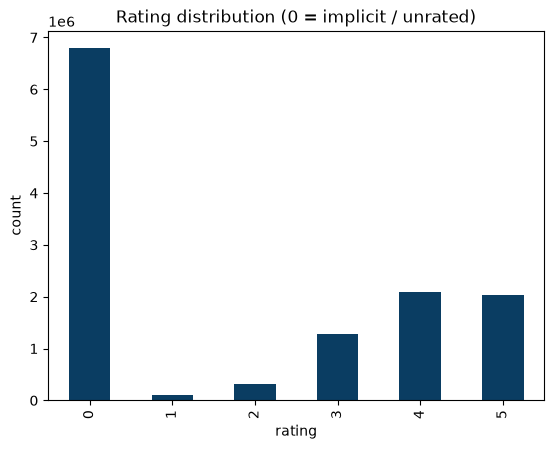

implicit (rating=0) share: 53.8%
explicit (1-5) interactions: 5,829,111


In [10]:
rc = sample.rating.value_counts().sort_index()
ax = rc.plot.bar(color='#0a3d62')
ax.set_title('Rating distribution (0 = implicit / unrated)'); ax.set_xlabel('rating'); ax.set_ylabel('count')
plt.show()
print('implicit (rating=0) share: %.1f%%' % (100*rc.get(0,0)/rc.sum()))
print('explicit (1-5) interactions: %s' % f'{int(rc.loc[1:].sum()):,}')

## Interactions per user

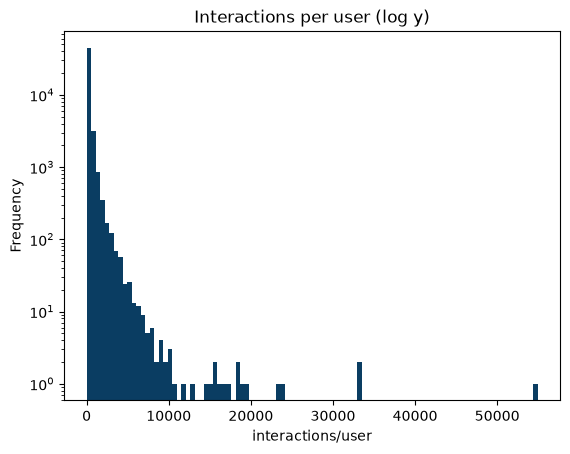

count    50000.0
mean       252.4
std        651.2
min         11.0
25%         47.0
50%        104.0
75%        246.0
max      54923.0


In [11]:
ipu = sample.groupby('user_id').size()
ipu.plot.hist(bins=100, log=True, color='#0a3d62')
plt.title('Interactions per user (log y)'); plt.xlabel('interactions/user'); plt.show()
print(ipu.describe().round(1).to_string())

### Heavy tail → history cap for sequential models

The distribution is extremely right-skewed — **mean ≫ median**, and the busiest user has
tens of thousands of interactions. A handful of power users hold a disproportionate share.
For **SASRec** we therefore **cap each user's history to their most recent N (=100)**: it
removes the RAM and training-time bloat from the tail without losing anything the model uses
(SASRec attends only to the last ~50 items). Together with user subsampling, this is what
shrinks the RecBole training set — e.g. **12.6M → ~2.3M interactions** on a 30k-user sample.

In [12]:
# Heavy tail -> why sequential models cap each user's history (our MAX_HIST in 06_recbole).
CAP = 100
total, kept = int(ipu.sum()), int(ipu.clip(upper=CAP).sum())
print(f"per-user: median {ipu.median():.0f} | mean {ipu.mean():.0f} | "
      f"p90 {ipu.quantile(.9):.0f} | p99 {ipu.quantile(.99):.0f} | max {ipu.max():,}")
print(f"users with > {CAP} interactions: {(ipu > CAP).mean():.1%}")
print(f"capping each user to their last {CAP}: {total:,} -> {kept:,} interactions "
      f"({1 - kept / total:.0%} removed -- almost all from the heavy tail)")

per-user: median 104 | mean 252 | p90 555 | p99 2316 | max 54,923
users with > 100 interactions: 51.1%
capping each user to their last 100: 12,618,544 -> 3,791,145 interactions (70% removed -- almost all from the heavy tail)


## Interactions per book (popularity long tail)

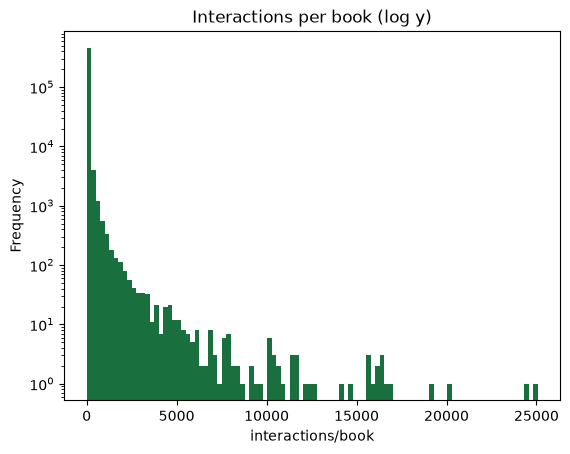

count    468628.0
mean         26.9
std         195.8
min           1.0
25%           2.0
50%           5.0
75%          14.0
max       25065.0
most-read book appears in 25065 sampled users


In [13]:
ipb = sample.groupby('book_id').size()
ipb.plot.hist(bins=100, log=True, color='#196f3d')
plt.title('Interactions per book (log y)'); plt.xlabel('interactions/book'); plt.show()
print(ipb.describe().round(1).to_string())
print('most-read book appears in', ipb.max(), 'sampled users')

## User–book matrix sparsity

In [14]:
n_u, n_b = sample.user_id.nunique(), sample.book_id.nunique()
density = len(sample)/(n_u*n_b)
print(f'users={n_u:,}  books={n_b:,}  interactions={len(sample):,}')
print(f'matrix density = {100*density:.4f}%   (sparsity = {1-density:.5f})')

users=50,000  books=468,628  interactions=12,618,544
matrix density = 0.0539%   (sparsity = 0.99946)


## Synopsis (description) length

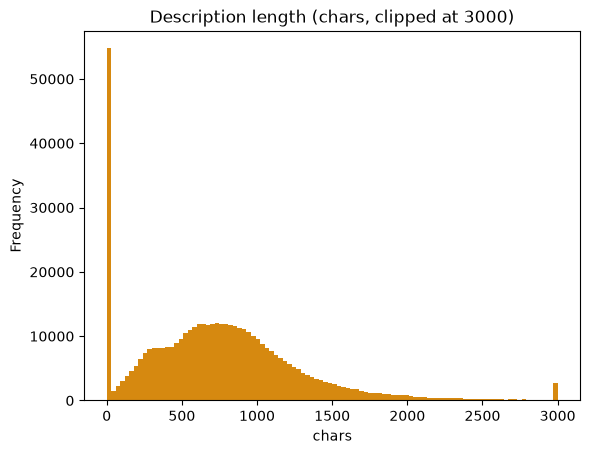

count    468628.0
mean        753.0
std         569.0
min           0.0
25%         373.0
50%         713.0
75%        1029.0
max       27051.0
empty descriptions: 53,957 (11.5%)


In [15]:
dl = catalog.description.fillna('').str.len()
dl.clip(upper=3000).plot.hist(bins=100, color='#d68910')
plt.title('Description length (chars, clipped at 3000)'); plt.xlabel('chars'); plt.show()
print(dl.describe().round(0).to_string())
print('empty descriptions:', f'{(dl==0).sum():,}', '(%.1f%%)' % (100*(dl==0).mean()))

## Shelf / genre signal (top tags)

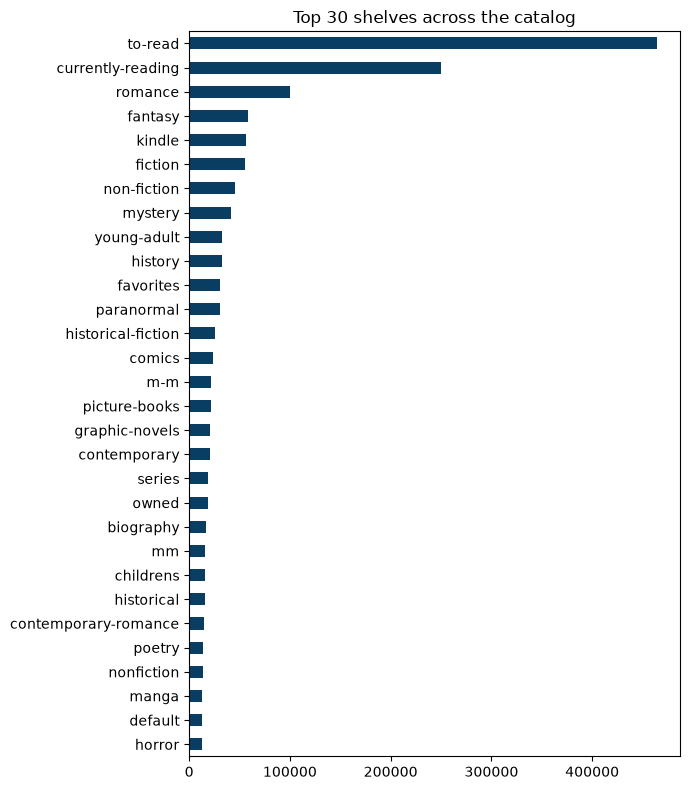

In [16]:
sc = Counter()
for s in catalog['shelves']:
    sc.update(list(s))
top = pd.Series(dict(sc.most_common(30)))
top.iloc[::-1].plot.barh(figsize=(7, 8), color='#0a3d62')
plt.title('Top 30 shelves across the catalog'); plt.tight_layout(); plt.show()

## Language mix
Note: the preprocess did **not** filter to English — non-English books are present.

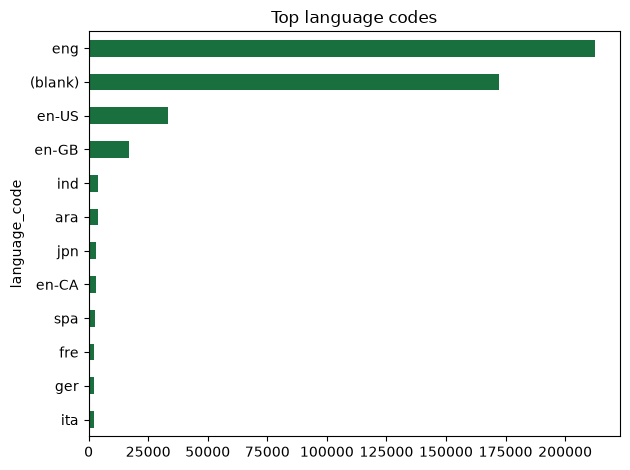

English-or-blank share: 93.5%


In [17]:
lc = catalog.language_code.replace('', '(blank)').value_counts().head(12)
lc.iloc[::-1].plot.barh(color='#196f3d')
plt.title('Top language codes'); plt.tight_layout(); plt.show()
eng = catalog.language_code.isin(['eng','en-US','en-GB','en-CA','en',''])
print('English-or-blank share: %.1f%%' % (100*eng.mean()))

## Temporal spread

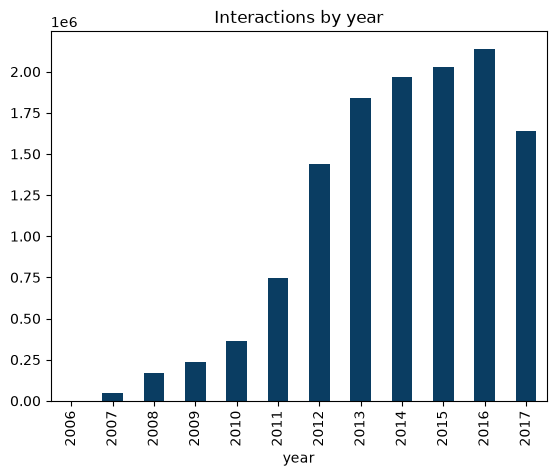

In [18]:
year = pd.to_datetime(sample.timestamp, unit='s').dt.year
year[year >= 2006].value_counts().sort_index().plot.bar(color='#0a3d62')
plt.title('Interactions by year'); plt.xlabel('year'); plt.show()

## Findings & anomalies

- **~54% of interactions are implicit (rating 0)** — explicit-only vs all-interactions is a real modeling fork (see the `filter_min_rating` ablation).
- **Heavy-tailed users** (median ~120, max ~68k interactions) and a **long-tail popularity** distribution over books — typical recsys skew; informs sampling/negatives.
- **Extremely sparse** user-book matrix (~0.04% dense) — motivates CF + content fusion.
- **~9% of books have empty descriptions** — content methods fall back to title + shelves for those.
- **Non-English books present** (language not filtered) — consider an English-only ablation.
- k-core floor visible: every user has ≥20 interactions, every book ≥10.